# Telecom X 2 - Customer Churn Model Training

Proyecto final de análisis de datos y ML sobre cancelaciones de clientes (churn) de una empresa de telecomunicaciones.

In [65]:
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import pickle


In [66]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Extracción

Carga de datos y normalización de columnas para su revisión y transformación

In [67]:
datos = 'data/TelecomX_Data.json'
df = pd.read_json(datos)
df = pd.json_normalize(df.to_dict(orient='records'), sep='_')
df.sample(10)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
2935,4079-VTGLK,No,Male,1,Yes,No,30,Yes,Yes,DSL,...,No,Yes,No,Yes,Yes,Two year,No,Electronic check,74.85,2181.75
3808,5213-TWWJU,No,Male,0,No,No,28,Yes,No,Fiber optic,...,No,Yes,Yes,No,Yes,Month-to-month,No,Electronic check,91.00,2626.15
3754,5160-UXJED,No,Male,0,No,Yes,17,Yes,No,DSL,...,No,No,No,No,No,One year,No,Mailed check,44.60,681.4
2249,3143-ILDAL,Yes,Male,0,No,No,56,Yes,Yes,Fiber optic,...,Yes,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,94.45,5124.6
4771,6537-QLGEX,No,Female,0,No,No,16,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,38.90,664.4
839,1194-HVAIF,No,Female,0,Yes,No,27,Yes,Yes,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),95.00,2462.55
7209,9919-KNPOO,No,Female,0,Yes,No,21,Yes,Yes,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,1948.35
1676,2378-HTWFW,No,Male,1,No,No,35,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,No,Credit card (automatic),91.00,3180.5
2238,3128-YOVTD,No,Female,0,Yes,Yes,51,Yes,No,Fiber optic,...,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.15,4018.55
3313,4619-EVPHY,No,Female,1,Yes,No,20,Yes,No,Fiber optic,...,No,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),91.00,1859.5


Eliminación de columnas que no son relevantes para ML

In [68]:
df.drop(columns=['customerID'], inplace=True)

Eliminacion de entradas sin datos de Churn

In [69]:
df = df.apply(lambda x: x.str.strip() if x.dtype in ['object', 'str'] else x)
df= df[df['Churn'] != ''].copy()

Relleno de datos vacíos en cargos y conversión de columnas a datos numéricos

In [70]:
df['account_Charges_Total'] = (df['account_Charges_Total'].replace('', 0).astype(float))

Limpieza lógica de columnas de servicios extra para hacerlas binarias

In [71]:
df['phone_MultipleLines'] = df['phone_MultipleLines'].replace('No phone service', 'No')
services_cols= ['internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport',
    'internet_StreamingTV',
    'internet_StreamingMovies']
df[services_cols] = df[services_cols].replace('No internet service', 'No')


Creación de columna para servicios extra de internet (feature engineering)

In [72]:
df['internet_extra_services_total'] = (df[services_cols]=='Yes').sum(axis=1)
df['internet_extra_services_total']

0       3
1       1
2       1
3       4
4       2
       ..
7262    2
7263    1
7264    1
7265    4
7266    5
Name: internet_extra_services_total, Length: 7043, dtype: int64

## Separación de los datos en conjuntos de entrenamiento, y prueba


Confirmamos si las clases de la variable a predecir están desbalanceados y hacemos el split de lso datos estratificados, para su evaluación y transformación

In [73]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [74]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999, stratify=y)

## Selección de variables para el entrenamiento

Revisar variables numéricas respecto a churn para confirmar si tienen impacto en la predicción

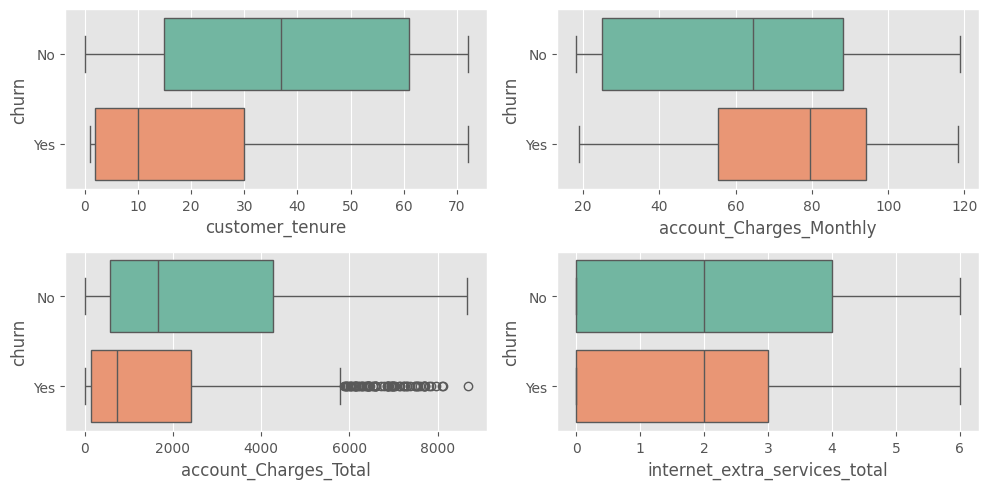

In [75]:
columnas_numericas = [
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total',
    'internet_extra_services_total'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(
        x=X_train[col],
        y=y_train,
        ax=axes[i],
        palette='Set2',
        hue=y_train,
        legend=False
    )

    axes[i].set_ylabel('churn')

plt.tight_layout()
plt.show()

Buscar correlaciones para elegir variables para el entrenamiento

In [76]:
# Matriz de correlaciones de Pearson sobre variables numéricas
X_train[columnas_numericas].corr(numeric_only=True)
# Alta correlación entre cargos totales y antigüedad de los clientes y cantidad de servicios extra

,customer_tenure,account_Charges_Monthly,account_Charges_Total,internet_extra_services_total
customer_tenure,1.000000,0.256219,0.827512,0.492850
account_Charges_Monthly,0.256219,1.000000,0.655826,0.727824
account_Charges_Total,0.827512,0.655826,1.000000,0.743560
internet_extra_services_total,0.492850,0.727824,0.743560,1.000000


Alta correlación entre cargos totales y antigüedad de los clientes y cantidad de servicios extra.

Revisar colinearidad entre columnas numéricas con alta correlación.

In [77]:
X_train_num = X_train[columnas_numericas]
X_train_num_con_constante = sm.add_constant(X_train_num)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_num_con_constante.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_num_con_constante.values, i) for i in range(X_train_num_con_constante.shape[1])]

print(vif_data[vif_data['Variable'] != 'const'])
# Encontramos alta colinearidad en la columna account_Charges_Total

                        Variable        VIF
1                customer_tenure   5.841156
2        account_Charges_Monthly   3.732054
3          account_Charges_Total  10.238986
4  internet_extra_services_total   2.891181


In [78]:
columnas_numericas = [
    'customer_tenure',
    'account_Charges_Monthly',
    'internet_extra_services_total'
]
X_train_num = X_train[columnas_numericas]
X_train_num_con_constante = sm.add_constant(X_train_num)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_num_con_constante.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_num_con_constante.values, i) for i in range(X_train_num_con_constante.shape[1])]

print(vif_data[vif_data['Variable'] != 'const'])
# No encontramos alta colinearidad en las columnas restantes

                        Variable       VIF
1                customer_tenure  1.360982
2        account_Charges_Monthly  2.191069
3  internet_extra_services_total  2.704043


Revisar variables categóricas respecto a churn para confirmar si tienen impacto en la predicción

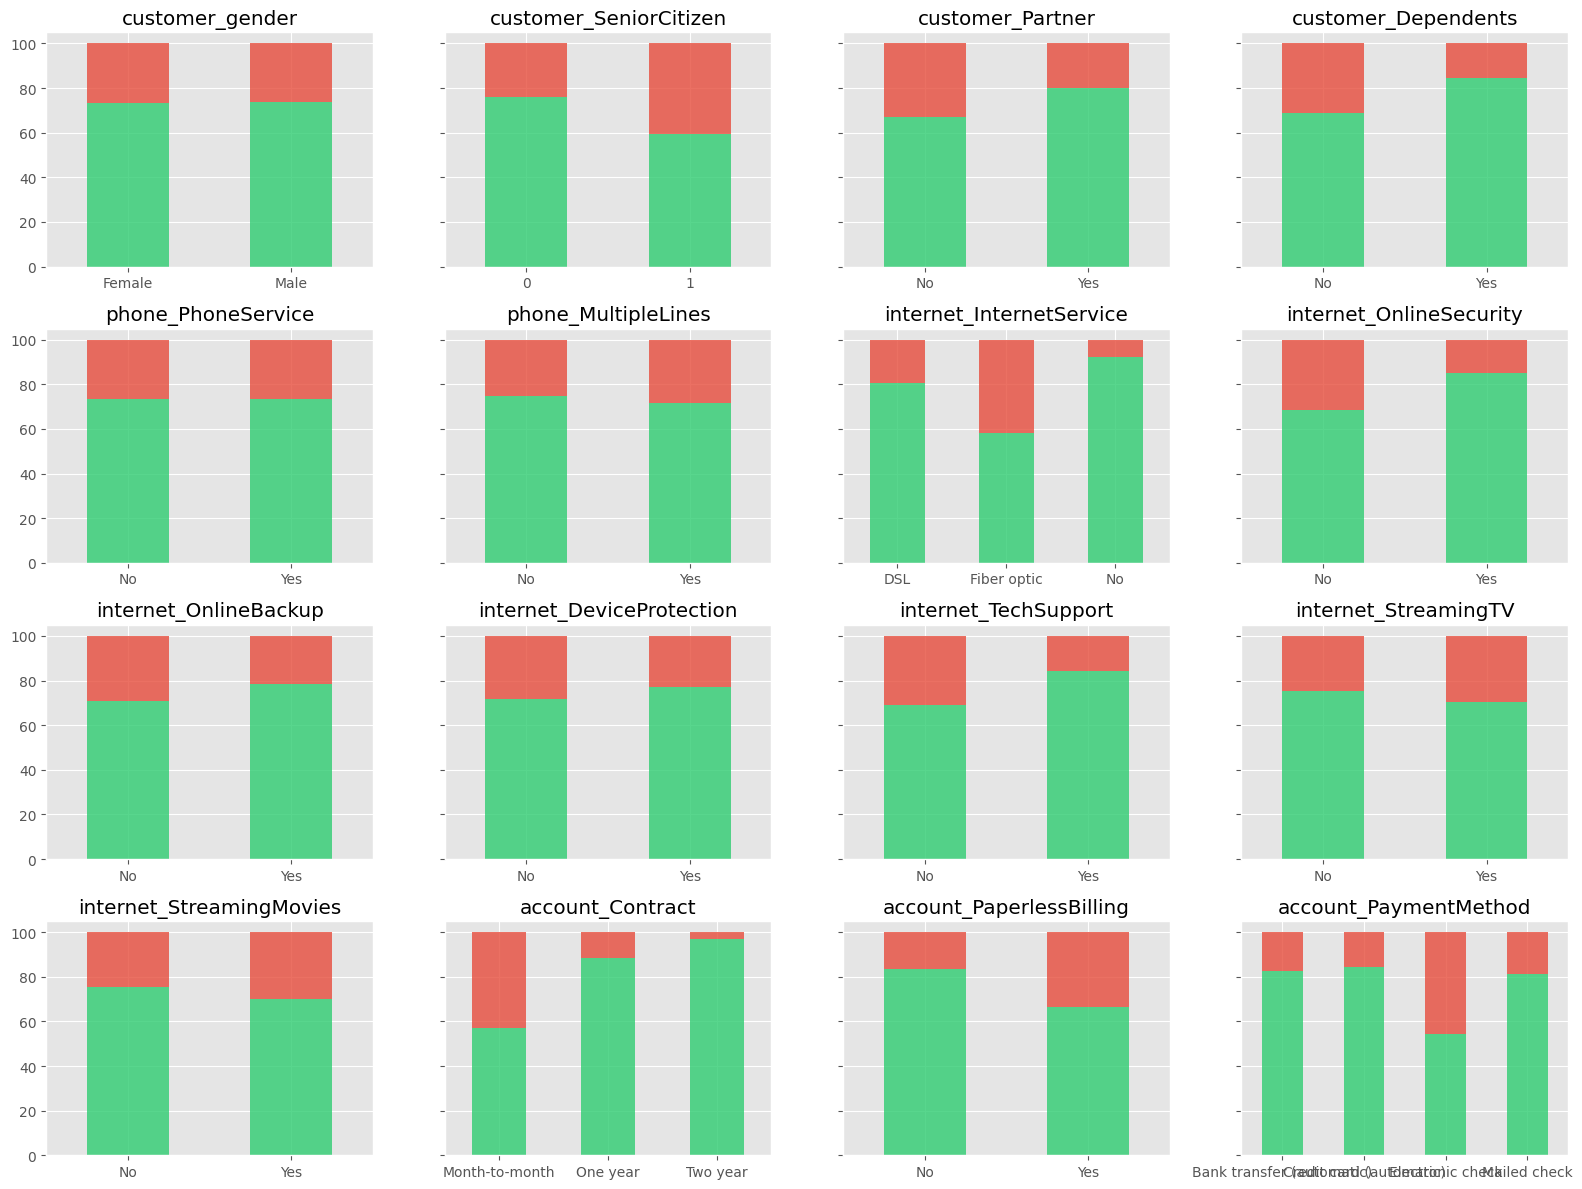

In [79]:
columnas_categoricas = ['customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod']

fig, axes = plt.subplots(nrows=4, ncols=len(columnas_categoricas)//4, figsize=(16,12), sharey=True)
axes = axes.flatten()

for i, col in enumerate(columnas_categoricas):

    df_plot = pd.crosstab(X_train[col], y_train, normalize='index') * 100
    df_plot.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()
plt.show()

Posible bajo impacto en el churn de las variables `'customer_gender', 'phone_PhoneService'`, y probablemente bajo en `'phone_MultipleLines','internet_StreamingTV', 'internet_StreamingMovies'`. Revisión con prueba de Chi-cuadrado (>0.05)

In [80]:
variables_a_evaluar = [
    'customer_gender',
    'phone_PhoneService',
    'phone_MultipleLines',
    'internet_StreamingTV',
    'internet_StreamingMovies'
]
for col in variables_a_evaluar:
    tabla = pd.crosstab(y_train, X_train[col])
    chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla)
    print(f'Valor p {col}: {p_valor:.5f}')

Valor p customer_gender: 0.73753
Valor p phone_PhoneService: 1.00000
Valor p phone_MultipleLines: 0.00946
Valor p internet_StreamingTV: 0.00003
Valor p internet_StreamingMovies: 0.00001


Revisión de colinealidad de variables categóricas

In [81]:
# Eliminamos columnas que no tienen impacto en el churn
columnas_categoricas = [col for col in columnas_categoricas if col not in ['customer_gender', 'phone_PhoneService']]

def calcular_v_cramer(columna1, columna2):
    tabla = pd.crosstab(columna1, columna2)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    if min_dim == 0: return 0.0
    return np.sqrt(chi2 / (n * min_dim))

matriz_cramer = pd.DataFrame(index=columnas_categoricas, columns=columnas_categoricas)

for col1 in columnas_categoricas:
    for col2 in columnas_categoricas:
        matriz_cramer.loc[col1, col2] = calcular_v_cramer(X_train[col1], X_train[col2])

matriz_cramer = matriz_cramer.astype(float)

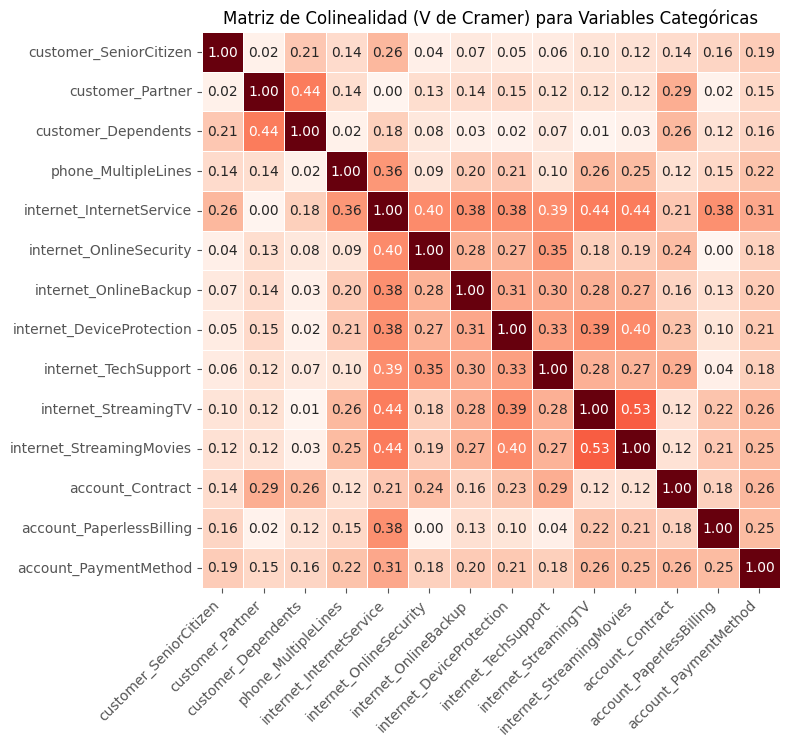

No hay una alta colinealidad entre las variables categóricas


In [82]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    matriz_cramer,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

plt.title("Matriz de Colinealidad (V de Cramer) para Variables Categóricas", fontsize=12)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')

plt.show()
print('No hay una alta colinealidad entre las variables categóricas')

Eliminación de columnas redundantes o innecesarias por bajo impacto en el churn o alta colinealidad con otras.

In [83]:
X_train.drop(columns=['account_Charges_Total', 'customer_gender', 'phone_PhoneService',], inplace=True)
X_train

,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,internet_extra_services_total
2603,0,No,No,62,No,No,No,No,No,No,No,No,Two year,Yes,Credit card (automatic),20.05,0
819,0,Yes,Yes,41,Yes,DSL,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),74.55,4
4559,0,Yes,Yes,70,Yes,DSL,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),80.60,4
3815,0,No,No,32,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,91.05,2
3142,0,No,No,17,No,No,No,No,No,No,No,No,One year,Yes,Mailed check,20.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,0,Yes,Yes,72,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),65.70,6
3652,0,No,No,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.70,0
4700,0,No,No,7,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,1
5217,0,No,No,38,Yes,Fiber optic,No,No,Yes,Yes,Yes,No,One year,No,Bank transfer (automatic),95.00,3


## Preprocesamiento

Conversión de variables objetivo a datos numéricos para evitar problemas en el entrenamiento.

In [84]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test= y_test.map({'No': 0, 'Yes': 1})

Separación de datos de validación

In [85]:
y_train.shape

(5634,)

In [86]:
X_train_select, X_val, y_train_select, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=999, stratify=y_train)

Encoding one-hot y escalado de datos

In [87]:
var_cat_entrenamiento = ['customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents',
                               'phone_MultipleLines', 'internet_InternetService','internet_OnlineSecurity',
                               'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
                               'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
                               'account_PaperlessBilling', 'account_PaymentMethod']
var_num_entrenamiento = ['customer_tenure', 'account_Charges_Monthly', 'internet_extra_services_total']

In [88]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Transformación de columnas categóricas y numéricas
matriz_cat = encoder.fit_transform(X_train_select[var_cat_entrenamiento])
matriz_num = scaler.fit_transform(X_train_select[var_num_entrenamiento])
nuevos_nombres_cat = encoder.get_feature_names_out(var_cat_entrenamiento)

# Guardado en Dataframes y unión como  nuevo conjunto procesado
df_cat_transformado = pd.DataFrame(matriz_cat, columns=nuevos_nombres_cat, index=X_train_select.index)
df_num_transformado = pd.DataFrame(matriz_num, columns=var_num_entrenamiento, index=X_train_select.index)
X_train_procesado = pd.concat([df_num_transformado, df_cat_transformado], axis=1)
X_train_procesado

,customer_tenure,account_Charges_Monthly,internet_extra_services_total,customer_SeniorCitizen_1,customer_Partner_Yes,customer_Dependents_Yes,phone_MultipleLines_Yes,internet_InternetService_Fiber optic,internet_InternetService_No,internet_OnlineSecurity_Yes,...,internet_DeviceProtection_Yes,internet_TechSupport_Yes,internet_StreamingTV_Yes,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
5731,-0.590374,0.687038,-0.556312,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1898,1.177634,-1.031162,-0.016978,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4185,1.588799,-1.299215,-1.095647,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6153,1.383216,0.497236,1.601025,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3152,-1.207121,-1.475696,-1.095647,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4307,-0.014744,-1.490681,-1.095647,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2821,1.588799,-0.105465,1.601025,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2907,-1.207121,0.190891,-1.095647,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1059,-0.179209,0.996713,0.522356,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


Aplicación del mismo proceso para los datos de validación

In [89]:
matriz_cat = encoder.transform(X_val[var_cat_entrenamiento])
matriz_num = scaler.transform(X_val[var_num_entrenamiento])
nuevos_nombres_cat = encoder.get_feature_names_out(var_cat_entrenamiento)

# Guardado en Dataframes y unión como  nuevo conjunto procesado
df_cat_transformado = pd.DataFrame(matriz_cat, columns=nuevos_nombres_cat, index=X_val.index)
df_num_transformado = pd.DataFrame(matriz_num, columns=var_num_entrenamiento, index=X_val.index)
X_val = pd.concat([df_num_transformado, df_cat_transformado], axis=1)

## Comparación de modelos

Oversampling para balancear datos de entrenamiento ya que la variable objetivo presenta muchos menos casos positivos de churn que negativos

In [90]:
y_train_select.value_counts()

Churn
0    3104
1    1121
Name: count, dtype: int64

In [91]:
smote = SMOTE(sampling_strategy='minority', random_state=999)
X_train_bal, y_train_bal = smote.fit_resample(X_train_procesado, y_train_select)

In [92]:
y_train_bal.value_counts()

Churn
1    3104
0    3104
Name: count, dtype: int64

Entrenamiento de modelos de _Regresión Logística_, _Random Forest_, y _Support Vector Machines (SVM)_ con parámetros sin optimizar

In [93]:
modelo_lr = LogisticRegression(random_state=999)
modelo_rf = RandomForestClassifier(max_depth=7, random_state=999)
modelo_svm = SVC(random_state=999)

modelo_lr.fit(X_train_bal, y_train_bal)
modelo_rf.fit(X_train_bal, y_train_bal)
modelo_svm.fit(X_train_bal, y_train_bal)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Comparación de scores de cada modelo

In [94]:
modelos = {'Regresión Logística': modelo_lr, 'Random Forest': modelo_rf, 'SVM': modelo_svm}

for nombre, modelo in modelos.items():
    predicciones = modelo.predict(X_val)

    # Calificamos comparando contra y_test_num (donde 1 = Abandonó, 0 = Se quedó)
    # pos_label=1 le indica a la métrica que nuestro objetivo es encontrar a los que se van
    recall = recall_score(y_val, predicciones, pos_label=1)
    precision = precision_score(y_val, predicciones, pos_label=1)
    accuracy = accuracy_score(y_val, predicciones)
    f1 = f1_score(y_val, predicciones)

    print(f"{nombre}:")
    print(f"   Recall:          {recall:.4f}")
    print(f"   Precision:       {precision:.4f}")
    print(f"   Accuracy:        {accuracy:.4f}")
    print(f"   F1-score:        {f1:.4f}")

Regresión Logística:
   Recall:          0.7701
   Precision:       0.5152
   Accuracy:        0.7466
   F1-score:        0.6174
Random Forest:
   Recall:          0.7406
   Precision:       0.5389
   Accuracy:        0.7630
   F1-score:        0.6239
SVM:
   Recall:          0.7246
   Precision:       0.5356
   Accuracy:        0.7601
   F1-score:        0.6159


En base a los resultados, elegimos el modelo de Regresión Lineal, que tiene un **Recall** significativamente más alto, lo cual es imperativo para nuestro problema de churn de clientes.

## Pipeline

Creación de un pipeline con el modelo de regresión para hacer validación cruzada y obtener parámetros optimizados

In [95]:
# Escalado y onehot encoding de los datos de entrenamiento
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), var_num_entrenamiento),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), var_cat_entrenamiento)
    ])

# Instanciando del pipeline y ajustando para preprocesamiento, oversampling y entrenamiento de cada fold
pipeline = ImbPipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('balanceo', SMOTE(random_state=999)),
    ('modelo', LogisticRegression(max_iter=1000, random_state=999))
])

hiperparametros = [
    # Bloque 1: El motor que nos permite probar el castigo L1 (Lasso) y L2
    {
        'modelo__solver': ['liblinear'],
        'modelo__penalty': ['l1', 'l2'],
        'modelo__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'modelo__class_weight': [None, 'balanced']
    },
    # Bloque 2: Los motores de alta precisión que solo aceptan el castigo L2
    {
        'modelo__solver': ['lbfgs', 'newton-cg'],
        'modelo__penalty': ['l2'],
        'modelo__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'modelo__class_weight': [None, 'balanced']
    }
]

# Validación cruzada con GridSearchCV usando los hiperparametros
metricas = {'Recall': 'recall', 'Precision': 'precision', 'Accuracy': 'accuracy', 'F1': 'f1'}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=hiperparametros,
    scoring=metricas,
    refit='Recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Usamos todo el conjunto de entrenamiento antes del split de los datos de validación que hicimos anteriormente
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=999))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo__C': [0.0001, 0.001, ...], 'modelo__class_weight': [None, 'balanced'], 'modelo__penalty': ['l1', 'l2'], 'modelo__solver': ['liblinear']}, {'modelo__C': [0.0001, 0.001, ...], 'modelo__class_weight': [None, 'balanced'], 'modelo__penalty': ['l2'], 'modelo__solver': ['lbfgs', 'newton-cg']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'Recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

Resultados de la validación cruzada

In [96]:
resultados_df = pd.DataFrame(grid_search.cv_results_)

columnas_ver = ['mean_test_Recall', 'mean_test_Precision', 'mean_test_Accuracy', 'mean_test_F1', 'param_modelo__C', 'param_modelo__penalty', 'param_modelo__solver']
tabla_resumen = resultados_df[columnas_ver].sort_values(by='mean_test_Recall', ascending=False)

tabla_resumen.columns = ['Recall', 'Precision', 'Accuracy', 'F1', 'Fuerza_C', 'Castigo', 'Motor']
print(tabla_resumen.to_string(index=False))

  Recall  Precision  Accuracy       F1  Fuerza_C Castigo     Motor
0.842140   0.468082  0.704117 0.601685    0.0001      l2 liblinear
0.842140   0.468082  0.704117 0.601685    0.0001      l2 liblinear
0.798662   0.493724  0.729144 0.610173    0.0100      l1 liblinear
0.798662   0.493724  0.729144 0.610173    0.0100      l1 liblinear
0.793980   0.504572  0.738373 0.616968    0.0010      l2 liblinear
0.793980   0.504572  0.738373 0.616968    0.0010      l2 liblinear
0.782609   0.510936  0.743520 0.618216    0.1000      l1 liblinear
0.782609   0.510936  0.743520 0.618216    0.1000      l1 liblinear
0.781940   0.514576  0.746359 0.620658    1.0000      l2 liblinear
0.781940   0.513466  0.745472 0.619850    1.0000      l1 liblinear
0.781940   0.514576  0.746359 0.620658    1.0000      l2 liblinear
0.781940   0.513466  0.745472 0.619850    1.0000      l1 liblinear
0.781940   0.516340  0.747779 0.621953    0.1000      l2 newton-cg
0.781940   0.516340  0.747779 0.621953    0.1000      l2 newto

El primer modelo presenta un recall más alto que los demás sin que su precisión sea demasiado baja, por lo que lo seleccionamos como modelo campéon.

In [97]:
modelo_final = grid_search.best_estimator_

Reporte de clasificación usando el conjunto de prueba

In [98]:
# 1. Calculamos las predicciones con tu modelo campeón (por si también se borró esta línea)
predicciones_test = modelo_final.predict(X_test)

# 2. Imprimimos el resumen ejecutivo con todas las métricas juntas
reporte = classification_report(y_test, predicciones_test)
print(reporte)

              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.48      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



Matriz de confusión del modelo final

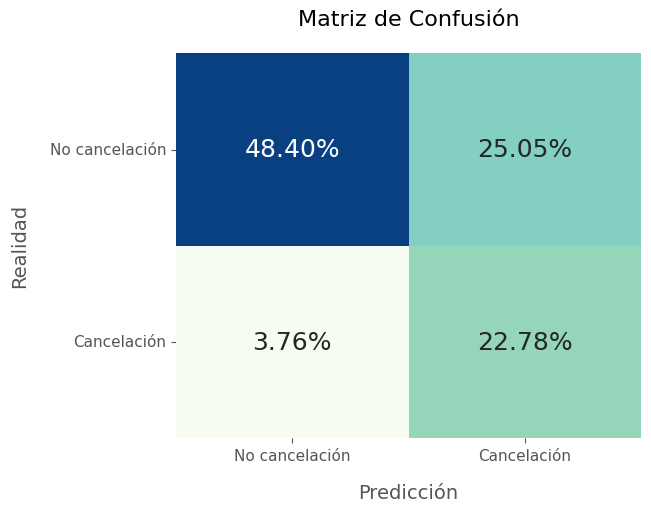

In [99]:
predicciones_test = modelo_final.predict(X_test)
matriz = confusion_matrix(y_test, predicciones_test)

plt.figure(figsize=(6, 5))

ax = sns.heatmap(matriz/np.sum(matriz), annot=True, fmt='.2%', cmap='GnBu',
                 cbar=False, annot_kws={"size": 18}, # Números grandes
                 xticklabels=['No cancelación', 'Cancelación'],
                 yticklabels=['No cancelación', 'Cancelación'])

plt.title('Matriz de Confusión', fontsize=16, pad=20)
plt.xlabel('Predicción', fontsize=14, labelpad=15)
plt.ylabel('Realidad', fontsize=14, labelpad=15)

plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.show()

Área bajo la curva de ROC

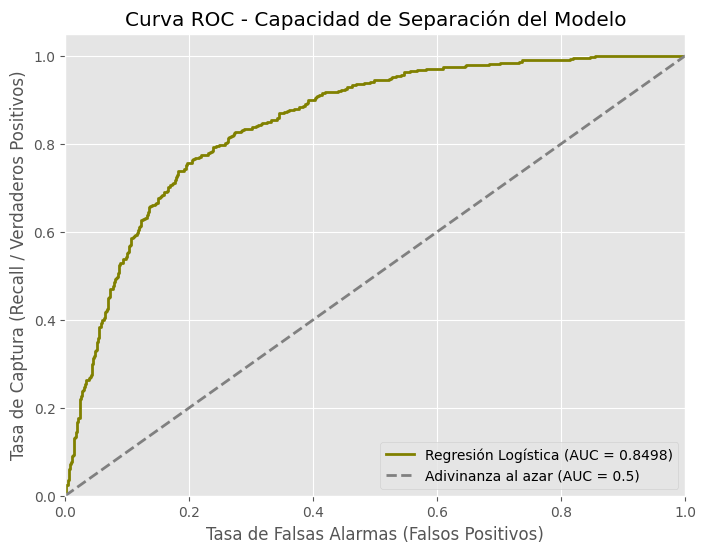

Valor del AUC ROC: 0.8498


In [100]:
probabilidades_test = grid_search.predict_proba(X_test)[:, 1]

fpr, tpr, umbrales = roc_curve(y_test, probabilidades_test)
auc_score = roc_auc_score(y_test, probabilidades_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='olive', lw=2, label=f'Regresión Logística (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Adivinanza al azar (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsas Alarmas (Falsos Positivos)')
plt.ylabel('Tasa de Captura (Recall / Verdaderos Positivos)')
plt.title('Curva ROC - Capacidad de Separación del Modelo')
plt.legend(loc="lower right")
plt.style.use('ggplot')

plt.show()

print(f"Valor del AUC ROC: {auc_score:.4f}")

Extracción de los coeficientes del modelo de regresión logística para encontrar las variables más importantes:

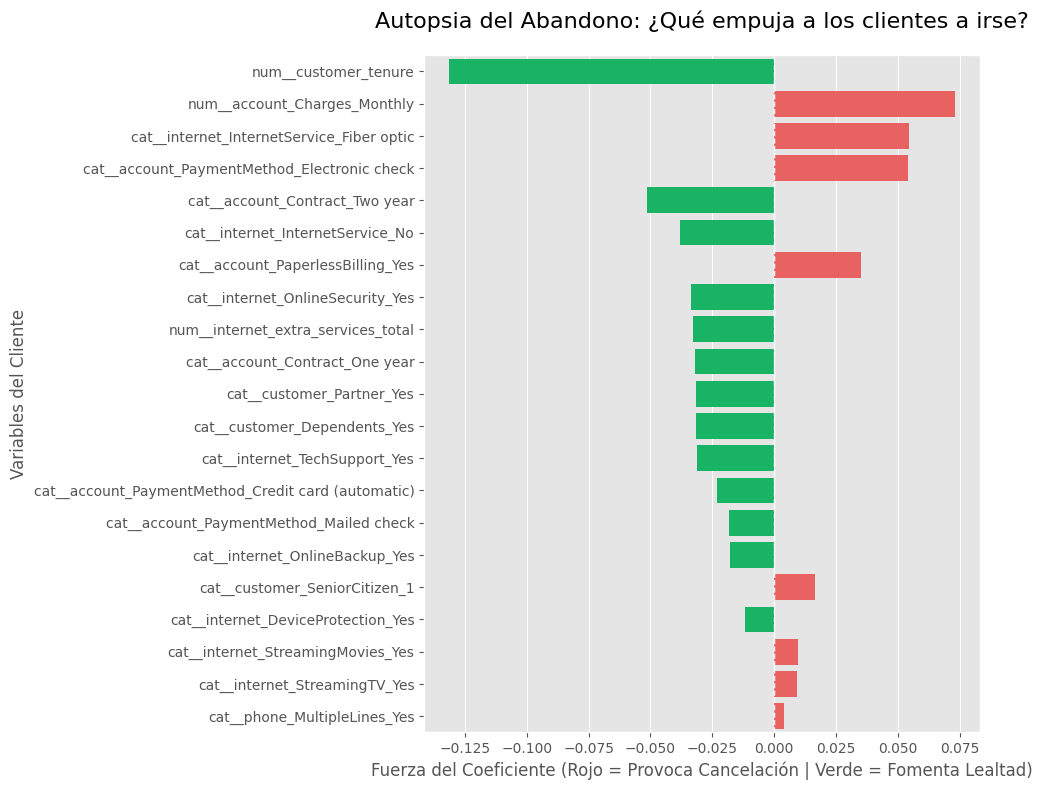

In [101]:
regresion_logistica = modelo_final.named_steps['modelo']
coeficientes = regresion_logistica.coef_[0]
nombres_columnas = modelo_final[:-1].get_feature_names_out()

importancia_df = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': coeficientes
})

importancia_df['Absoluto'] = importancia_df['Importancia'].abs()
importancia_df = importancia_df.sort_values(by='Absoluto', ascending=False).drop(columns=['Absoluto'])

plt.figure(figsize=(10, 8))

colores = ['#ff4c4c' if x > 0 else '#00cc66' for x in importancia_df['Importancia']]

sns.barplot(data=importancia_df, x='Importancia', y='Variable', palette=colores, legend=False, hue='Variable')

plt.title('Autopsia del Abandono: ¿Qué empuja a los clientes a irse?', fontsize=16, pad=20)
plt.xlabel('Fuerza del Coeficiente (Rojo = Provoca Cancelación | Verde = Fomenta Lealtad)', fontsize=12)
plt.ylabel('Variables del Cliente', fontsize=12)

plt.axvline(x=0, color='white', linestyle='--', linewidth=1)

plt.style.use('ggplot')
plt.tight_layout()
plt.show()

Guardado del modelo

In [102]:
nombre_archivo_pickle = 'modelo_churn_produccion.pkl'

with open(nombre_archivo_pickle, 'wb') as archivo:
    pickle.dump(modelo_final, archivo)

print(f"Modelo guardado como '{nombre_archivo_pickle}'")

Modelo guardado como 'modelo_churn_produccion.pkl'
